In [44]:
import mlflow
import os
import pandas as pd


In [45]:
MLFLOW_SERVER_IP = "192.168.1.103"
MLFLOW_SERVER_IP = "localhost"
# MLflow
os.environ["MLFLOW_TRACKING_URI"] = f"http://{MLFLOW_SERVER_IP}:5000"

import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
# MinIO
os.environ["AWS_ACCESS_KEY_ID"] = "minioadmin"
os.environ["AWS_SECRET_ACCESS_KEY"] = "minioadmin"
os.environ["MLFLOW_S3_ENDPOINT_URL"] = f"http://{MLFLOW_SERVER_IP}:9000"

def get_exp_trials(experiment_name, return_artifacts = True, timeout=10):
    """
    Get all trials (runs) from a specific MLFlow experiment.
    
    Args:
        experiment_name (str): Name of the MLflow experiment
        timeout (int): Timeout in seconds for operations (default: 10)
        
    Returns:
        pd.DataFrame: DataFrame containing all runs with their metrics, parameters, and metadata
        None: If experiment not found or connection fails
    """
    tracking_uri = os.environ.get("MLFLOW_TRACKING_URI")
    print(f"Testing connection to MLflow server: {tracking_uri}")
    
    # Test if server is reachable
    try:
        response = requests.get(tracking_uri, timeout=5)
        print(f"✓ MLflow server is reachable (status: {response.status_code})")
    except requests.exceptions.Timeout:
        print("✗ Connection timed out. Server might be down or unreachable.")
        return None
    except requests.exceptions.ConnectionError:
        print("✗ Connection error. Check if server is running and network is available.")
        return None
    except Exception as e:
        print(f"✗ Error connecting to server: {e}")
        return None
    
    # Set timeout for MLflow operations
    os.environ["MLFLOW_HTTP_REQUEST_TIMEOUT"] = str(timeout)
    
    print(f"Creating MLflow client...")
    client = mlflow.tracking.MlflowClient()
    
    print(f"Getting experiment: '{experiment_name}'...")
    try:
        # Get the experiment by name
        experiment = client.get_experiment_by_name(experiment_name)
        print(f"✓ Found experiment: {experiment.name if experiment else None}")
    except Exception as e:
        print(f"✗ Error getting experiment: {e}")
        return None
    
    if not experiment:
        print(f"✗ MLflow experiment '{experiment_name}' not found.")
        return None
    
    # Search all runs in the experiment
    print(f"Searching for runs in experiment...")
    try:
        runs = client.search_runs(
            experiment_ids=[experiment.experiment_id],
            order_by=["start_time DESC"]  # Most recent first
        )
        print(f"✓ Found {len(runs)} runs")
    except Exception as e:
        print(f"✗ Error searching runs: {e}")
        return None
    
    if not runs:
        print(f"⚠ No runs found in experiment '{experiment_name}'")
        return pd.DataFrame()

    # Convert runs to dicts
    print(f"Converting {len(runs)} runs to DataFrame...")
    runs_data = []
    artifacts = {}
    for run in runs:
        run_dict = {
            'run_id': run.info.run_id,
            'run_name': run.info.run_name,
            'status': run.info.status,
            'start_time': pd.to_datetime(run.info.start_time, unit='ms'),
            'end_time': pd.to_datetime(run.info.end_time, unit='ms') if run.info.end_time else None,
        }
        
        # Add all metrics, params, and tags
        run_dict.update({f'metric_{k}': v for k, v in run.data.metrics.items()})
        #run_dict.update({f'param_{k}': v for k, v in run.data.params.items()})
        #run_dict.update({f'tag_{k}': v for k, v in run.data.tags.items()})

        print(run.info.artifact_uri)

        if return_artifacts:
            artifacts[run_dict['run_name']] = None
        
        runs_data.append(run_dict)
    
    df = pd.DataFrame(runs_data)
    print(f"✓ Successfully created DataFrame with {len(df)} rows and {len(df.columns)} columns")

    if return_artifacts:
        return df, artifacts
    return df


In [46]:
# Get all trials from an experiment

exp_name = 'daily_search3'
time = "Daily"

# Call with timeout parameter (default is 10 seconds, increase if needed)
trials_df, artifacts = get_exp_trials(exp_name, timeout=15)

# Display the results
if trials_df is not None and not trials_df.empty:
    print(f"\n📊 Retrieved {len(trials_df)} trials")
    display(trials_df.head())

Testing connection to MLflow server: http://localhost:5000
✓ MLflow server is reachable (status: 200)
Creating MLflow client...
Getting experiment: 'daily_search3'...
✓ Found experiment: daily_search3
Searching for runs in experiment...
✓ Found 100 runs
Converting 100 runs to DataFrame...
s3://mlflow/26/ab2d4a1ebd3f41c08668ed277b5c1db3/artifacts
s3://mlflow/26/39fd2d941f1d4d259d36e8b77fff0c36/artifacts
s3://mlflow/26/5b4d424cc6e64d75ba9d6db5112d44cc/artifacts
s3://mlflow/26/81f29274b9544931b4f554a4f589c9bc/artifacts
s3://mlflow/26/aa2099cd96cd4637bb08e1802b815f46/artifacts
s3://mlflow/26/b7aa76afd4ff49619a3dbae286a87623/artifacts
s3://mlflow/26/58ca28b47f294b34a225b7176d51e3ad/artifacts
s3://mlflow/26/078b262e42fb41fba91c0ec6001aa3eb/artifacts
s3://mlflow/26/7c61df2fcf334ed190b68b3e1c51cedd/artifacts
s3://mlflow/26/36b726e5c4fd46b1a0ae0d73bc9b6c0a/artifacts
s3://mlflow/26/8de8ed77fda148a897b5bf1564fbdb3a/artifacts
s3://mlflow/26/38138e6dc2ba45359aa2309212f6fcb4/artifacts
s3://mlflow/26

,run_id,run_name,status,start_time,end_time,metric_train_mse_loss,metric_vali_mse_loss,metric_vali_mda_metric,metric_test_mse_loss,metric_test_mda_metric,...,metric_inf_pred_5_mda,metric_inf_pred_6_mda,metric_inf_pred_7_mda,metric_inf_pred_8_mda,metric_inf_pred_9_mda,metric_inf_pred_10_mda,metric_inf_pred_11_mda,metric_inf_pred_12_mda,metric_inf_pred_13_mda,metric_inf_pred_14_mda
0,ab2d4a1ebd3f41c08668ed277b5c1db3,trial_a557cb40_daily_full_dates_2016-01-01_202...,FINISHED,2025-12-05 14:07:18.221,2025-12-05 14:19:01.164,0.003596,0.002285,0.491587,0.001492,0.500000,...,0.506064,0.506623,0.493923,0.495575,0.506091,0.515521,0.524972,0.512222,0.523915,0.527840
1,39fd2d941f1d4d259d36e8b77fff0c36,trial_f25b2294_daily_full_dates_2016-01-01_202...,FINISHED,2025-12-05 13:55:57.369,2025-12-05 14:06:59.061,0.004605,0.003716,0.500000,0.001786,0.498798,...,0.504961,0.507726,0.495028,0.497788,0.507198,0.526608,0.524972,0.514444,0.523915,0.538976
2,5b4d424cc6e64d75ba9d6db5112d44cc,trial_1b56fbd2_daily_full_dates_2016-01-01_202...,FINISHED,2025-12-05 13:42:55.644,2025-12-05 13:55:38.471,0.002805,0.002081,0.484375,0.001377,0.507212,...,0.507166,0.507726,0.493923,0.495575,0.502769,0.517738,0.530522,0.513333,0.525028,0.534521
3,81f29274b9544931b4f554a4f589c9bc,trial_22ba3a60_daily_full_dates_2016-01-01_202...,FINISHED,2025-12-05 13:30:08.787,2025-12-05 13:42:36.942,0.001595,0.000878,0.537260,0.000992,0.489183,...,0.502756,0.506623,0.497238,0.494469,0.501661,0.518847,0.523862,0.514444,0.523915,0.527840
4,aa2099cd96cd4637bb08e1802b815f46,trial_54c21e53_daily_full_dates_2016-01-01_202...,FINISHED,2025-12-05 13:17:06.871,2025-12-05 13:29:50.017,0.001794,0.001039,0.527644,0.001039,0.495192,...,0.503859,0.506623,0.497238,0.496681,0.501661,0.519956,0.524972,0.514444,0.525028,0.528953


In [47]:
df = trials_df.copy()
df.head()

,run_id,run_name,status,start_time,end_time,metric_train_mse_loss,metric_vali_mse_loss,metric_vali_mda_metric,metric_test_mse_loss,metric_test_mda_metric,...,metric_inf_pred_5_mda,metric_inf_pred_6_mda,metric_inf_pred_7_mda,metric_inf_pred_8_mda,metric_inf_pred_9_mda,metric_inf_pred_10_mda,metric_inf_pred_11_mda,metric_inf_pred_12_mda,metric_inf_pred_13_mda,metric_inf_pred_14_mda
0,ab2d4a1ebd3f41c08668ed277b5c1db3,trial_a557cb40_daily_full_dates_2016-01-01_202...,FINISHED,2025-12-05 14:07:18.221,2025-12-05 14:19:01.164,0.003596,0.002285,0.491587,0.001492,0.500000,...,0.506064,0.506623,0.493923,0.495575,0.506091,0.515521,0.524972,0.512222,0.523915,0.527840
1,39fd2d941f1d4d259d36e8b77fff0c36,trial_f25b2294_daily_full_dates_2016-01-01_202...,FINISHED,2025-12-05 13:55:57.369,2025-12-05 14:06:59.061,0.004605,0.003716,0.500000,0.001786,0.498798,...,0.504961,0.507726,0.495028,0.497788,0.507198,0.526608,0.524972,0.514444,0.523915,0.538976
2,5b4d424cc6e64d75ba9d6db5112d44cc,trial_1b56fbd2_daily_full_dates_2016-01-01_202...,FINISHED,2025-12-05 13:42:55.644,2025-12-05 13:55:38.471,0.002805,0.002081,0.484375,0.001377,0.507212,...,0.507166,0.507726,0.493923,0.495575,0.502769,0.517738,0.530522,0.513333,0.525028,0.534521
3,81f29274b9544931b4f554a4f589c9bc,trial_22ba3a60_daily_full_dates_2016-01-01_202...,FINISHED,2025-12-05 13:30:08.787,2025-12-05 13:42:36.942,0.001595,0.000878,0.537260,0.000992,0.489183,...,0.502756,0.506623,0.497238,0.494469,0.501661,0.518847,0.523862,0.514444,0.523915,0.527840
4,aa2099cd96cd4637bb08e1802b815f46,trial_54c21e53_daily_full_dates_2016-01-01_202...,FINISHED,2025-12-05 13:17:06.871,2025-12-05 13:29:50.017,0.001794,0.001039,0.527644,0.001039,0.495192,...,0.503859,0.506623,0.497238,0.496681,0.501661,0.519956,0.524972,0.514444,0.525028,0.528953


In [48]:
df.drop(columns=['run_id', 'status', 'start_time', 'end_time'], inplace=True)
df['start'] = df['run_name'].str.split('_').str[5]
df['end'] = df['run_name'].str.split('_').str[6]
df['start'] = pd.to_datetime(df['start'], format='%Y-%m-%d %H:%M:%S')
df['end'] = pd.to_datetime(df['end'], format='%Y-%m-%d %H:%M:%S')
df.head()


,run_name,metric_train_mse_loss,metric_vali_mse_loss,metric_vali_mda_metric,metric_test_mse_loss,metric_test_mda_metric,metric_inf_pred_1_mse,metric_inf_pred_2_mse,metric_inf_pred_3_mse,metric_inf_pred_4_mse,...,metric_inf_pred_7_mda,metric_inf_pred_8_mda,metric_inf_pred_9_mda,metric_inf_pred_10_mda,metric_inf_pred_11_mda,metric_inf_pred_12_mda,metric_inf_pred_13_mda,metric_inf_pred_14_mda,start,end
0,trial_a557cb40_daily_full_dates_2016-01-01_202...,0.003596,0.002285,0.491587,0.001492,0.500000,0.000976,0.003654,0.001098,0.001290,...,0.493923,0.495575,0.506091,0.515521,0.524972,0.512222,0.523915,0.527840,2016-01-01,2020-12-31
1,trial_f25b2294_daily_full_dates_2016-01-01_202...,0.004605,0.003716,0.500000,0.001786,0.498798,0.000941,0.001620,0.001379,0.009532,...,0.495028,0.497788,0.507198,0.526608,0.524972,0.514444,0.523915,0.538976,2016-01-01,2020-12-31
2,trial_1b56fbd2_daily_full_dates_2016-01-01_202...,0.002805,0.002081,0.484375,0.001377,0.507212,0.001533,0.001285,0.002184,0.000904,...,0.493923,0.495575,0.502769,0.517738,0.530522,0.513333,0.525028,0.534521,2016-01-01,2020-12-31
3,trial_22ba3a60_daily_full_dates_2016-01-01_202...,0.001595,0.000878,0.537260,0.000992,0.489183,0.000996,0.000977,0.001007,0.001393,...,0.497238,0.494469,0.501661,0.518847,0.523862,0.514444,0.523915,0.527840,2016-01-01,2020-12-31
4,trial_54c21e53_daily_full_dates_2016-01-01_202...,0.001794,0.001039,0.527644,0.001039,0.495192,0.001080,0.001025,0.001094,0.001794,...,0.497238,0.496681,0.501661,0.519956,0.524972,0.514444,0.525028,0.528953,2016-01-01,2020-12-31


In [49]:
for col in df.columns:
    if col.split("_")[0] == "param":
        df.drop(columns=[col], inplace=True)
    elif col.split("_")[0] == "metric" and col.split("_")[-1] == "mda":
        pred = col.split("_")[-2]
        df.rename(columns={col: f"mda_{pred}"}, inplace=True)
    elif col.split("_")[0] == "metric" and col.split("_")[-1] == "mse":
        pred = col.split("_")[-2]
        df.rename(columns={col: f"mse_{pred}"}, inplace=True)
    elif col.split("_")[0] == "metric" and col.split("_")[1].lower() == "rmse":
        pred = col.split("_")[-1]
        df.rename(columns={col: f"rmse_{pred}"}, inplace=True)
    elif col.split("_")[0] == "tag":
        df.drop(columns=[col], inplace=True)
    elif col.split("_")[0] == "metric":
        name = "_".join(col.split("_")[1:])
        df.rename(columns={col: name}, inplace=True)



df.head()

print(df.columns)
df.sort_values(by="start", ascending=True, inplace=True)

Index(['run_name', 'train_mse_loss', 'vali_mse_loss', 'vali_mda_metric',
       'test_mse_loss', 'test_mda_metric', 'mse_1', 'mse_2', 'mse_3', 'mse_4',
       'mse_5', 'mse_6', 'mse_7', 'mse_8', 'mse_9', 'mse_10', 'mse_11',
       'mse_12', 'mse_13', 'mse_14', 'rmse_1', 'rmse_2', 'rmse_3', 'rmse_4',
       'rmse_5', 'rmse_6', 'rmse_7', 'rmse_8', 'rmse_9', 'rmse_10', 'rmse_11',
       'rmse_12', 'rmse_13', 'rmse_14', 'mda_1', 'mda_2', 'mda_3', 'mda_4',
       'mda_5', 'mda_6', 'mda_7', 'mda_8', 'mda_9', 'mda_10', 'mda_11',
       'mda_12', 'mda_13', 'mda_14', 'start', 'end'],
      dtype='object')


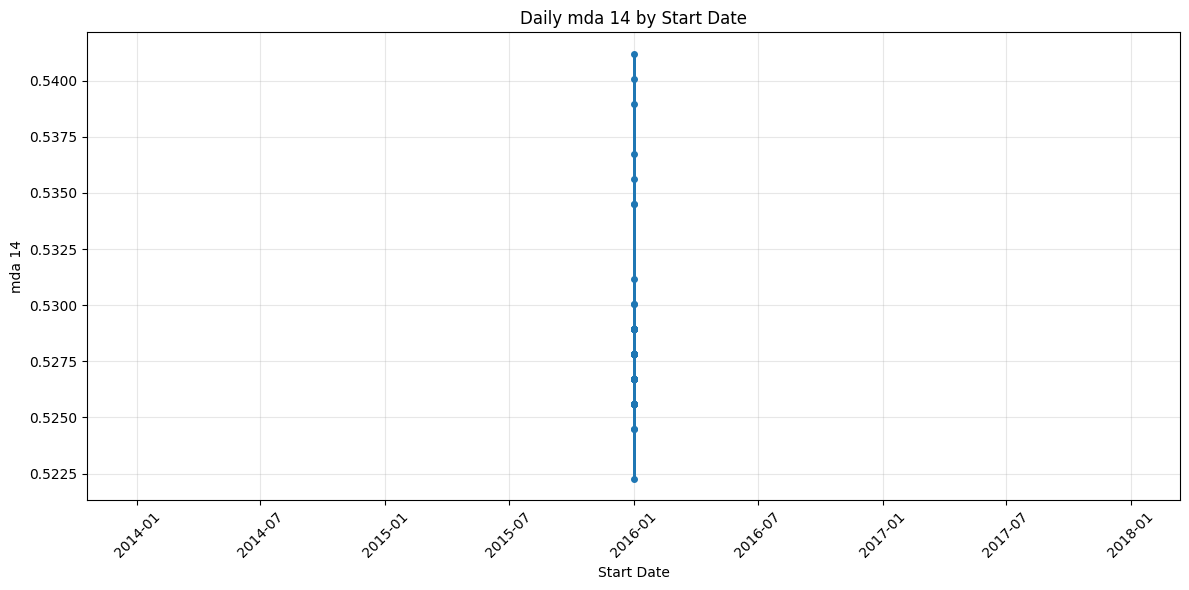

In [ ]:
import matplotlib.pyplot as plt

pred = 7
metric = "mda"


plt.figure(figsize=(12, 6))
plt.plot(df['start'], df[f'{metric}_{pred}'], marker='o', linewidth=2, markersize=4)
plt.xlabel('Start Date')
plt.ylabel(f'{metric} {pred}')
plt.title(f'{time} {metric} {pred} by Start Date')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'plots/{time}_mdas.png')

plt.show()


In [51]:
aggregated_metrics = df.drop(columns=['start', 'end','run_name']).mean()

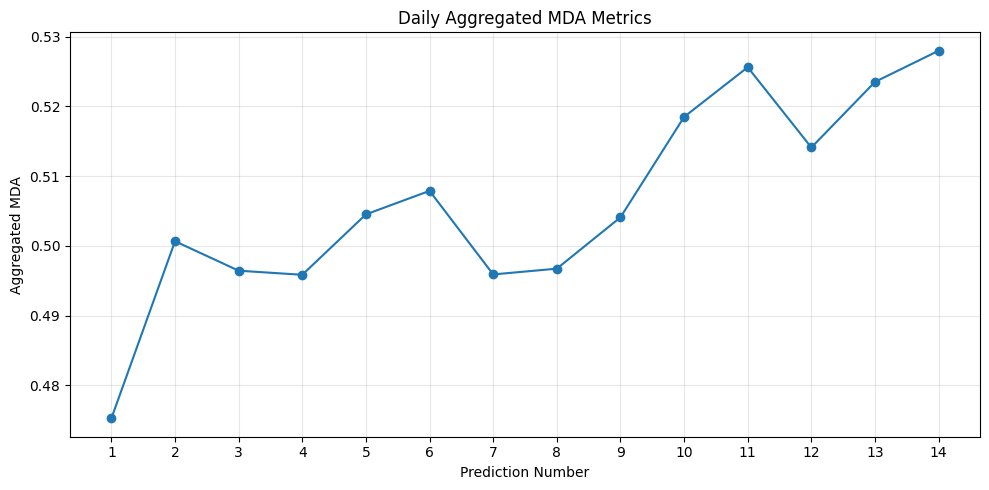

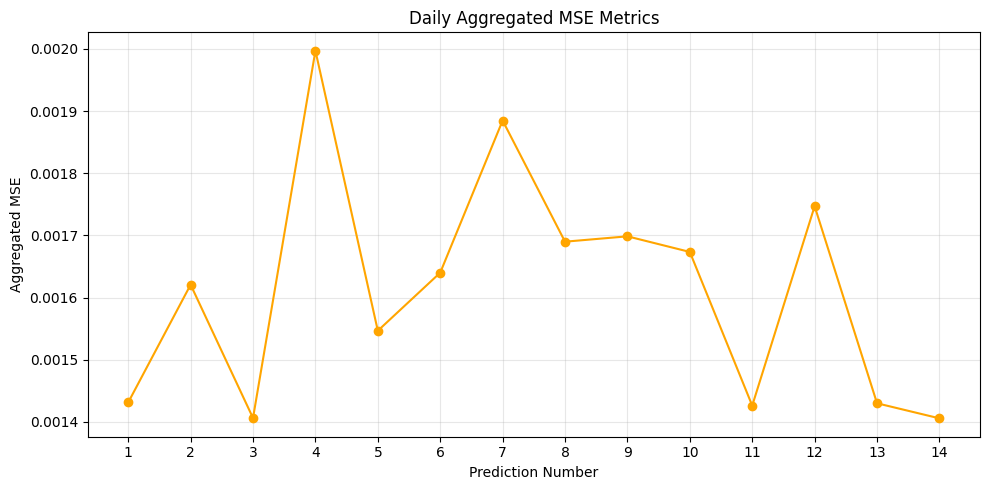

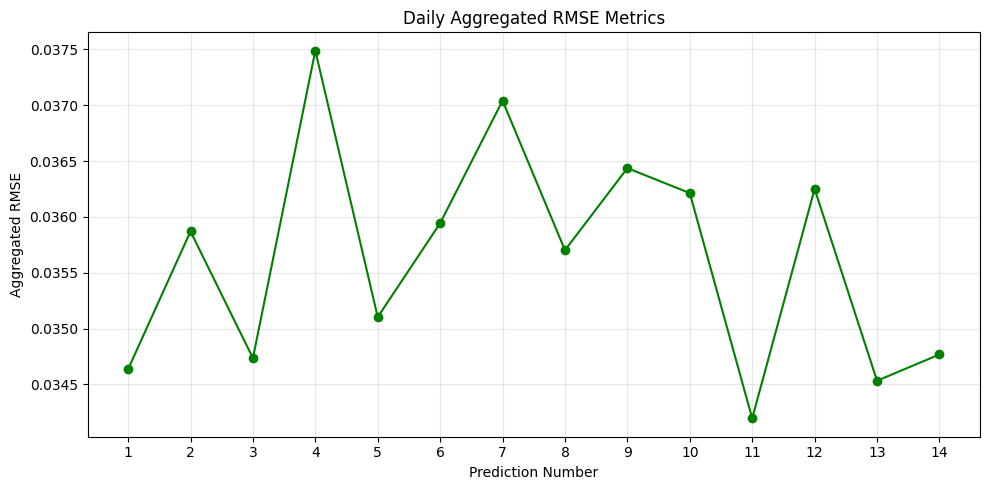

In [52]:
import re

# Get all metric names for mda, mse, and rmse
mda_cols = [col for col in aggregated_metrics.index if re.match(r"mda_\d+", col)]
mse_cols = [col for col in aggregated_metrics.index if re.match(r"mse_\d+", col)]
rmse_cols = [col for col in aggregated_metrics.index if re.match(r"rmse_\d+", col)]

# Extract numbers for sorting
def sort_key(col):
    return int(col.split('_')[1])

mda_cols_sorted = sorted(mda_cols, key=sort_key)
mse_cols_sorted = sorted(mse_cols, key=sort_key)
rmse_cols_sorted = sorted(rmse_cols, key=sort_key)

# Plot mda
plt.figure(figsize=(10, 5))
plt.plot(
    [int(col.split('_')[1]) for col in mda_cols_sorted],
    [aggregated_metrics[col] for col in mda_cols_sorted],
    marker='o', label='MDA'
)
plt.xlabel('Prediction Number')
plt.ylabel('Aggregated MDA')
plt.title(f'{time} Aggregated MDA Metrics')
plt.grid(True, alpha=0.3)
plt.xticks([int(col.split('_')[1]) for col in mda_cols_sorted])
plt.savefig(f'plots/{time}_mdas.png')
plt.tight_layout()
plt.show()

# Plot mse
plt.figure(figsize=(10, 5))
plt.plot(
    [int(col.split('_')[1]) for col in mse_cols_sorted],
    [aggregated_metrics[col] for col in mse_cols_sorted],
    marker='o', color='orange', label='MSE'
)
plt.xlabel('Prediction Number')
plt.ylabel('Aggregated MSE')
plt.title(f'{time} Aggregated MSE Metrics')
plt.grid(True, alpha=0.3)
plt.xticks([int(col.split('_')[1]) for col in mse_cols_sorted])
plt.savefig(f'plots/{time}_mses.png')
plt.tight_layout()
plt.show()

# Plot rmse
plt.figure(figsize=(10, 5))
plt.plot(
    [int(col.split('_')[1]) for col in rmse_cols_sorted],
    [aggregated_metrics[col] for col in rmse_cols_sorted],
    marker='o', color='green', label='RMSE'
)
plt.xlabel('Prediction Number')
plt.ylabel('Aggregated RMSE')
plt.title(f'{time} Aggregated RMSE Metrics')
plt.grid(True, alpha=0.3)
plt.xticks([int(col.split('_')[1]) for col in rmse_cols_sorted])
plt.tight_layout()

plt.show()
